h = 0.01
  |eigenvalues|: [1.00015 1.00015]
  -> Solution may not be Entirely Stable ;)

h = 0.02
  |eigenvalues|: [1.0006 1.0006]
  -> Solution may not be Entirely Stable ;)

h = 0.03
  |eigenvalues|: [1.001349 1.001349]
  -> Solution may not be Entirely Stable ;)

h = 0.05
  |eigenvalues|: [1.003743 1.003743]
  -> Solution may not be Entirely Stable ;)

h = 0.1
  |eigenvalues|: [1.014889 1.014889]
  -> Solution may not be Entirely Stable ;)

h = 0.2
  |eigenvalues|: [1.058301 1.058301]
  -> Solution may not be Entirely Stable ;)

h = 0.3
  |eigenvalues|: [1.126943 1.126943]
  -> Solution may not be Entirely Stable ;)

h = 0.5
  |eigenvalues|: [1.322876 1.322876]
  -> Solution may not be Entirely Stable ;)



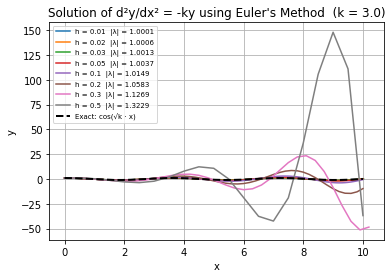

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters
k = 3.0
h1 = [.01, .02, .03, .05, .1, .2, .3, .5]
x_start = 0
x_end = 10
y_0 = 1.0
v_0 = 0.0

# System matrix A and exact solution for reference
A = np.array([[0, 1], [-k, 0]])

for h in h1:
    # Euler step matrix M = I + h*A
    M = np.eye(2) + h * A
    eigs = np.linalg.eigvals(M)
    mags = np.abs(eigs)
    stable = np.all(mags <= 1.0)

    print(f"h = {h}")
    print(f"  |eigenvalues|: {np.round(mags, 6)}")
    if stable:
        print("  -> Solution is Stable")
    else:
        print("  -> Solution may not be Entirely Stable ;)")
    print()

    # Create arrays to store x, y, and v values
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    # Euler's Method loop
    for i in range(1, len(x_values)):
        x_n = x_values[i - 1]
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]

        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)

    plt.plot(x_values, y_values, label=f'h = {h}  |λ| = {mags[0]:.4f}')

# Exact solution overlay
x_exact = np.linspace(x_start, x_end, 1000)
y_exact = np.cos(np.sqrt(k) * x_exact)
plt.plot(x_exact, y_exact, 'k--', linewidth=2, label='Exact: cos(√k · x)')

plt.xlabel('x')
plt.ylabel('y')
plt.title(f"Solution of d²y/dx² = -ky using Euler's Method  (k = {k})")
plt.legend(fontsize=7)
plt.grid(True)
plt.show()

# Interesting observation, the eigenvalues for a harmonic oscilator are never less than 1, so euler method is always unstable. It constantly adds/subtracts energy leading to inconsistencies.